In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

from models.fc_imv import FC_Marginal, JointVAE

import numpy as np
import pandas as pd
import copy

from sklearn.metrics import roc_curve, auc, confusion_matrix

import matplotlib.pyplot as plt

## Example of a forward pass on fake data

In [2]:
# two arbitrary views, one with 1000 features, and another with 500 features
marg_model1 = FC_Marginal(input_size=1000, hidden_sizes=[128, 128], z_dim=10, prediction_dim=10)
marg_model2 = FC_Marginal(input_size=500, hidden_sizes=[64, 64], z_dim=10, prediction_dim=10)

# joint model
joint_model = JointVAE(marginal_models=[marg_model1, marg_model2], hidden_dim=128)

# define optimizer
optimizer = AdamW(joint_model.parameters(), lr=1e-3)

In [3]:
# fake inputs/targets
example_input1 = torch.randn(100, 1000)
example_input2 = torch.randn(100, 500)
example_target = torch.randint(0, 10, (100,))

In [4]:
# get the predictions and distribution of the joint model, and the predictions and distributions of the marginal models
yhat, poe_dist, yhats, dists = joint_model([example_input1, example_input2])

In [5]:
# pass the predictions and distributions to the loss function and update parameters
loss = joint_model.loss(example_target, yhat, poe_dist, yhats, dists)
loss.backward()

## Example with real data

In [2]:
lipData = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_lipidpos_edata_log2_normalized.csv')
metabData = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_metab_edata_log2_normalized.csv')
proData = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_protein_edata_log2_normalized.csv')

fmeta = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_fmeta.csv')

In [3]:
# some samples missing from some datasets.
lipData.shape, metabData.shape, proData.shape

((250, 60), (133, 58), (3510, 61))

In [4]:
# filter all rows in fmeta where any of SampleID_proteomics, SampleID_proteomics, SampleID_metab are NA
fmeta = fmeta[~fmeta[['SampleID_proteomics', 'SampleID_lipidpos', 'SampleID_metab']].isna().any(axis=1)]
fmeta['Virus_y'] = fmeta.Virus.replace({'Cal[0-9]*': 'Cal'}, regex=True)
y = fmeta.Virus_y

In [5]:
# make the "LIPID" column in lipData the index
lipData = lipData.set_index('LIPID')
metabData = metabData.set_index('METABOLITE')
proData = proData.set_index('REFERENCE')

In [6]:
lipData = lipData.loc[:,lipData.columns.isin(fmeta['SampleID_lipidpos'])]
metabData = metabData.loc[:,metabData.columns.isin(fmeta['SampleID_metab'])]
proData = proData.loc[:,proData.columns.isin(fmeta['SampleID_proteomics'])]


In [7]:
# get the elements in lipData.columns that are in fmeta['SampleID_lipidpos']
lipData = lipData.loc[:,lipData.columns.isin(fmeta['SampleID_lipidpos'])]
metabData = metabData.loc[:,metabData.columns.isin(fmeta['SampleID_metab'])]
proData = proData.loc[:,proData.columns.isin(fmeta['SampleID_proteomics'])]

np.random.seed(1565)
cal_inds = np.random.choice(np.where(y == 'Cal')[0], 14)
mock_inds = np.random.choice(np.where(y == 'Mock')[0], 10)
test_inds = np.concatenate([cal_inds, mock_inds])

train_inds = np.isin(np.arange(y.shape[0]), test_inds) == False

train_lip = lipData.iloc[:,train_inds]
train_pro = proData.iloc[:,train_inds]
train_metab = metabData.iloc[:,train_inds]

test_lip = lipData.iloc[:, test_inds]
test_pro = proData.iloc[:, test_inds]
test_metab = metabData.iloc[:, test_inds]

ytrain = y.iloc[train_inds]
ytest = y.iloc[test_inds]

In [8]:
# drop protein rows with all NA values 

# get indices with all nan values
train_inds = (train_pro.isnull() == False).sum(axis = 1) > 0
test_inds = (test_pro.isnull() == False).sum(axis = 1) > 0

bad_inds = train_inds * test_inds

# drop bad_inds
train_pro = train_pro[bad_inds]
test_pro = test_pro[bad_inds]


In [9]:
# impute the datasets with the row means
train_lip = train_lip.apply(lambda row: row.fillna(row.mean()), axis=1)
train_pro = train_pro.apply(lambda row: row.fillna(row.mean()), axis=1)
train_metab = train_metab.apply(lambda row: row.fillna(row.mean()), axis=1)

test_lip = test_lip.apply(lambda row: row.fillna(row.mean()), axis=1)
test_pro = test_pro.apply(lambda row: row.fillna(row.mean()), axis=1)
test_metab = test_metab.apply(lambda row: row.fillna(row.mean()), axis=1)

In [10]:
assert all(lipData.columns == fmeta['SampleID_lipidpos'])
assert all(metabData.columns == fmeta['SampleID_metab'])
assert all(proData.columns == fmeta['SampleID_proteomics'])

### Construct the Model

In [54]:
# three view-specific encoders with the appropriate input size:
lip_marg = FC_Marginal(input_size=train_lip.shape[0], hidden_sizes=[128, 128], z_dim=10, prediction_dim=y.nunique())
metab_marg = FC_Marginal(input_size=train_metab.shape[0], hidden_sizes=[64, 64], z_dim=10, prediction_dim=y.nunique())
pro_marg = FC_Marginal(input_size=train_pro.shape[0], hidden_sizes=[256, 128], z_dim=10, prediction_dim=y.nunique(), dropout = 0.1)

# joint model
joint_model = JointVAE(marginal_models=[lip_marg, metab_marg, pro_marg], hidden_dim=128)

# define optimizer
optimizer = AdamW(joint_model.parameters(), lr=1e-4)

In [56]:
# turn data into tensors
lip_tensor = torch.tensor(train_lip.T.values, dtype=torch.float32)
pro_tensor = torch.tensor(train_pro.T.values, dtype=torch.float32)
metab_tensor = torch.tensor(train_metab.T.values, dtype=torch.float32)

y_gt = ytrain.astype('category').cat.codes
y_gt = torch.tensor(y_gt.values, dtype=torch.int64)

for i in range(1000):

    views = [lip_tensor, metab_tensor, pro_tensor]
    
    # randomly drop an index with low probability
    if np.random.rand() < 0.1:
        idx = np.random.randint(0, len(views))
        views = [v if i != idx else None for i, v in enumerate(views)]

    # get the predictions and distribution of the joint model, and the predictions and distributions of the marginal models
    yhat, poe_dist, yhats, dists = joint_model(views)

    # pass the predictions and distributions to the loss function and update parameters
    loss = joint_model.loss(y_gt, yhat, poe_dist, yhats, dists)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(joint_model.parameters(), 2.0)
    optimizer.step()

    print(f'Epoch {i+1} loss: {loss.item():.3f}')

Epoch 1 loss: 30.941
Epoch 2 loss: 24.957
Epoch 3 loss: 31.598
Epoch 4 loss: 31.412
Epoch 5 loss: 35.499
Epoch 6 loss: 32.883
Epoch 7 loss: 23.246
Epoch 8 loss: 31.762
Epoch 9 loss: 32.357
Epoch 10 loss: 28.926
Epoch 11 loss: 31.464
Epoch 12 loss: 34.366
Epoch 13 loss: 33.159
Epoch 14 loss: 33.460
Epoch 15 loss: 31.614
Epoch 16 loss: 32.447
Epoch 17 loss: 31.539
Epoch 18 loss: 30.598
Epoch 19 loss: 29.149
Epoch 20 loss: 31.467
Epoch 21 loss: 34.216
Epoch 22 loss: 34.067
Epoch 23 loss: 31.639
Epoch 24 loss: 30.591
Epoch 25 loss: 20.883
Epoch 26 loss: 32.094
Epoch 27 loss: 32.356
Epoch 28 loss: 33.874
Epoch 29 loss: 31.395
Epoch 30 loss: 20.426
Epoch 31 loss: 32.078
Epoch 32 loss: 31.581
Epoch 33 loss: 32.790
Epoch 34 loss: 28.946
Epoch 35 loss: 30.319
Epoch 36 loss: 30.843
Epoch 37 loss: 32.272
Epoch 38 loss: 31.310
Epoch 39 loss: 30.763
Epoch 40 loss: 33.198
Epoch 41 loss: 33.617
Epoch 42 loss: 30.000
Epoch 43 loss: 31.800
Epoch 44 loss: 33.886
Epoch 45 loss: 31.163
Epoch 46 loss: 29.8

In [57]:
# example prediction
joint_model.eval()

ytest_gt = ytest.astype('category').cat.codes

liptest_tensor = torch.tensor(test_lip.T.values, dtype=torch.float32)
protest_tensor = torch.tensor(test_pro.T.values, dtype=torch.float32)
metabtest_tensor = torch.tensor(test_metab.T.values, dtype=torch.float32)

with torch.inference_mode():
    yhat, poe_dist, yhats, dists = joint_model([liptest_tensor, metabtest_tensor, protest_tensor])

ypred = yhat.argmax(dim=1).numpy()

(ypred == ytest_gt.to_numpy()).mean()

0.875

In [58]:
confusion_matrix(ytest_gt, ypred)

array([[12,  2],
       [ 1,  9]])

In [59]:
# order is lip metab pro
(
    (yhats[0].argmax(dim=1).numpy() == ytest_gt.to_numpy()).mean(),
    (yhats[1].argmax(dim=1).numpy() == ytest_gt.to_numpy()).mean(),
    (yhats[2].argmax(dim=1).numpy() == ytest_gt.to_numpy()).mean()
)

(0.7916666666666666, 0.7083333333333334, 0.5416666666666666)

In [60]:
pred_lip = yhats[0].argmax(dim=1).numpy()
pred_pro = yhats[1].argmax(dim=1).numpy()
pred_metab = yhats[2].argmax(dim=1).numpy()

(
    confusion_matrix(ytest_gt.to_numpy(), pred_lip),
    confusion_matrix(ytest_gt.to_numpy(), pred_pro),
    confusion_matrix(ytest_gt.to_numpy(), pred_metab)
)

(array([[11,  3],
        [ 2,  8]]),
 array([[9, 5],
        [2, 8]]),
 array([[7, 7],
        [4, 6]]))

# Variable Importance

## Gradient analysis

As a first pass for variable importance, I simply take the gradient of input input w.r.t. the predicted output probability of the positive class.  Essentially I am trying to determine which input biomolecules are important for the ability of the model to predict the positive class.

In [61]:
# get a single positive example (-1, the last example is positive)
liptest_pos = torch.clone(liptest_tensor[-1].unsqueeze(0))
protest_pos = torch.clone(protest_tensor[-1].unsqueeze(0))
metabtest_pos = torch.clone(metabtest_tensor[-1].unsqueeze(0))

liptest_pos.requires_grad = True
protest_pos.requires_grad = True
metabtest_pos.requires_grad = True

yhat, poe_dist, yhats, dists = joint_model([liptest_pos, metabtest_pos, protest_pos])


In [62]:
yhat[0,1].backward()

In [64]:
# get the gradients and multiply by the input
# (
# liptest_pos.grad.abs().argsort()[:,:10],
# protest_pos.grad.abs().argsort()[:,:10],
# metabtest_pos.grad.abs().argsort()[:,:10]
# )

liptest_scores = liptest_pos.grad * liptest_pos
protest_scores = protest_pos.grad * protest_pos
metabtest_scores = metabtest_pos.grad * metabtest_pos

(
liptest_scores.argsort()[:,:10],
protest_scores.argsort()[:,:10],
metabtest_scores.argsort()[:,:10]
)

(tensor([[  3,  35,   5, 152, 189,  59, 153,  23, 236, 170]]),
 tensor([[1569, 1033, 1566, 1728,    5,  207, 1875, 2841, 1397,  653]]),
 tensor([[108,  70,  61, 118,  66,  18,  42, 124,  17, 107]]))

In [65]:
liptest_pos = torch.clone(liptest_tensor[ytest_gt.to_numpy() == 1])
protest_pos = torch.clone(protest_tensor[ytest_gt.to_numpy() == 1])
metabtest_pos = torch.clone(metabtest_tensor[ytest_gt.to_numpy() == 1])

liptest_pos.requires_grad = True
protest_pos.requires_grad = True
metabtest_pos.requires_grad = True

yhat, poe_dist, yhats, dists = joint_model([liptest_pos, metabtest_pos, protest_pos])

In [66]:
yhat[:,1].mean().backward()

In [67]:
# (
# liptest_pos.grad.abs().sum(axis=0).argsort()[:10],
# protest_pos.grad.abs().sum(axis=0).argsort()[:10],
# metabtest_pos.grad.abs().sum(axis=0).argsort()[:10]
# )

liptest_scores = liptest_pos.grad * liptest_pos
protest_scores = protest_pos.grad * protest_pos
metabtest_scores = metabtest_pos.grad * metabtest_pos

(
liptest_scores.sum(axis = 0).argsort()[:10],
protest_scores.sum(axis = 0).argsort()[:10],
metabtest_scores.sum(axis = 0).argsort()[:10]
)

(tensor([  3,  59,  35,   5, 153, 225,  45, 152, 106, 189]),
 tensor([1569,    5, 1033, 1566, 1875, 1728, 1397,  207, 3090, 2841]),
 tensor([108,  70, 118,  61,  66,  29, 110, 124, 107,  18]))

# Integrated Gradients

Integrated gradients overcome the problem of non-sensitivity of gradients methods, see https://arxiv.org/pdf/1703.01365.pdf for an explanation.  

As described in the paper, we start at some 'non-informative' baseline, and move linearly towards our actual input, taking the gradient at each step and accumulating.  At the end we divide by the number of steps to get the average gradient, which approximates and integral.  This is the integrated gradient.

In [125]:
liptest_pos = torch.clone(liptest_tensor[ytest_gt.to_numpy() == 1])
protest_pos = torch.clone(protest_tensor[ytest_gt.to_numpy() == 1])
metabtest_pos = torch.clone(metabtest_tensor[ytest_gt.to_numpy() == 1])

# baseline is normal noise with mean and std from the data
lip_baseline = torch.randn_like(liptest_pos)*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
pro_baseline = torch.randn_like(protest_pos)*protest_pos.std().numpy() + protest_pos.mean().numpy()
metab_baseline = torch.randn_like(metabtest_pos)*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()

In [138]:
# move along the baseline (noise) to input, take the gradient at each step, and accumulate.  Divide at the end to form an average.
# lip_baseline = torch.randn_like(liptest_pos, requires_grad = True)*liptest_pos.std() + liptest_pos.mean()
# pro_baseline = torch.randn_like(protest_pos, requires_grad = True)*protest_pos.std() + protest_pos.mean()
# metab_baseline = torch.randn_like(metabtest_pos, requires_grad = True)*metabtest_pos.std() + metabtest_pos.mean()

grad_lip = torch.zeros_like(lip_baseline)
grad_pro = torch.zeros_like(pro_baseline)
grad_metab = torch.zeros_like(metab_baseline)

n_steps = 100

for i in range(1, n_steps + 1):
    tmp_lip = torch.clone(lip_baseline)
    tmp_pro = torch.clone(pro_baseline)
    tmp_metab = torch.clone(metab_baseline)

    tmp_lip = tmp_lip + i * (liptest_pos - tmp_lip)/n_steps
    tmp_pro = tmp_pro + i * (protest_pos - tmp_pro)/n_steps
    tmp_metab = tmp_metab + i * (metabtest_pos - tmp_metab)/n_steps

    tmp_lip.requires_grad = True
    tmp_pro.requires_grad = True
    tmp_metab.requires_grad = True

    yhat, poe_dist, yhats, dists = joint_model([tmp_lip, tmp_metab, tmp_pro])

    yhat[:,1].mean().backward()

    grad_lip += tmp_lip.grad
    grad_pro += tmp_pro.grad
    grad_metab += tmp_metab.grad


In [139]:
lip_int_scores = grad_lip * (liptest_pos - lip_baseline) / n_steps
pro_int_scores = grad_pro * (protest_pos - pro_baseline) / n_steps
metab_int_scores = grad_metab * (metabtest_pos - metab_baseline) / n_steps

In [151]:
top_lip = lip_int_scores.sum(axis = 0).argsort()[:10]
top_pro = pro_int_scores.sum(axis = 0).argsort()[:10]
top_metab = metab_int_scores.sum(axis = 0).argsort()[:10]

(
top_lip,
top_pro,
top_metab
)

(tensor([106, 115,  55,  56, 179, 100,  59,  48, 241,  78]),
 tensor([1569, 3060, 1510, 1566,    5, 1874,  516, 1508, 1490, 2812]),
 tensor([  5,   7, 126, 128,  59, 123,  61,  70,  23, 127]))

In [157]:
(
test_lip.iloc[top_lip.numpy(), :].index,
test_pro.iloc[top_pro.numpy(), :].index,
test_metab.iloc[top_metab.numpy(), :].index
)

(Index(['PC(O-16:0/16:1)', 'PC(O-18:0/18:1)', 'PC(10:0/18:1)', 'PC(12:0/18:2)',
        'PS(18:1/0:0)', 'PC(20:1/0:0)_A', 'PC(14:0/16:0)', 'PC(0:0/16:0)_A',
        'TG(54:2)', 'PC(17:1/0:0)'],
       dtype='object', name='LIPID'),
 Index(['KRT35_HUMAN', 'TBB8_HUMAN', 'K2C8_HUMAN', 'KPYM_HUMAN', '1433T_HUMAN',
        'NDKA_HUMAN', 'CEP55_HUMAN', 'K2C7_HUMAN', 'K1H2_HUMAN', 'SH3G2_HUMAN'],
       dtype='object', name='REFERENCE'),
 Index(['adenosine', 'aminomalnoic acid*', 'Unknown 058', 'Unknown 060',
        'O-phosphocolamine', 'Unknown 055', 'phosphate ion', 'uracil',
        'D-ribose-5-phosphate', 'Unknown 059'],
       dtype='object', name='METABOLITE'))

# Train on TCGA

The TCGA dataset was processed as in (Lee and van der Schaar, 2021).  The features are kernel-PCA representations of the
TCGA gene expression data.  The labels are the 1 year mortality status of the patients.

In [2]:
# load pre-processed tcga data
tcgadata = np.load('/Users/clab683/Documents/Data/tcga/multi_omics_1yr_mortality.npz')

In [3]:
rnaseq = torch.tensor(tcgadata['mRNAseq']).float()
methyl = torch.tensor(tcgadata['Methylation']).float()
mirna = torch.tensor(tcgadata['miRNAseq']).float()
rppa = torch.tensor(tcgadata['RPPA']).float()
labels = torch.tensor(tcgadata['label']).reshape(-1).long()

# sample train indices
train_inds = np.random.choice(len(rnaseq), size=int(len(rnaseq) * 0.7), replace=False)
valid_inds = np.setdiff1d(np.arange(len(rnaseq)), train_inds)
test_inds = np.random.choice(valid_inds, size=int(len(valid_inds) * 0.5), replace=False)
valid_inds = np.setdiff1d(valid_inds, test_inds)

# create train, valid, and test tensors
rnaseq_train = rnaseq[train_inds]
methyl_train = methyl[train_inds]
mirna_train = mirna[train_inds]
rppa_train = rppa[train_inds]
labels_train = labels[train_inds]

rnaseq_valid = rnaseq[valid_inds]
methyl_valid = methyl[valid_inds]
mirna_valid = mirna[valid_inds]
rppa_valid = rppa[valid_inds]
labels_valid = labels[valid_inds]

rnaseq_test = rnaseq[test_inds]
methyl_test = methyl[test_inds]
mirna_test = mirna[test_inds]
rppa_test = rppa[test_inds]
labels_test = labels[test_inds]

# dataloaders
train_dataset = torch.utils.data.TensorDataset(rnaseq_train, methyl_train, mirna_train, rppa_train, labels_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = torch.utils.data.TensorDataset(rnaseq_valid, methyl_valid, mirna_valid, rppa_valid, labels_valid)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=32, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(rnaseq_test, methyl_test, mirna_test, rppa_test, labels_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)

### Build the model

In [183]:
# reload these modules with sys and importlib
import sys
import importlib

# import the modules
importlib.reload(sys.modules['models.fc_imv'])
from models.fc_imv import FC_Marginal, JointVAE

# three view-specific encoders with the appropriate input size:
marg_model = FC_Marginal(input_size=100, hidden_sizes=[256, 256], z_dim=32, prediction_dim=labels.unique().size()[0])

# joint model
joint_model = JointVAE(marginal_models=[copy.deepcopy(marg_model) for _ in range(4)], hidden_dim=128)

# define optimizer
optimizer = AdamW(joint_model.parameters(), lr=1e-4)

## Training

To facilitate training, we need to group samples into sub-batches with similar view-missing patterns.  In a single batch, there may be several sub-batches that we feed through the model one by one.  We accumulate the loss over these sub-batches and update the gradients one all sub-batches have been passed forward.

The classes are heavily imbalanced, about 80% of patients survive to 1 year.  I use a class-balanced focal loss to address this issue.

In [184]:
# a function to build batches that group together batches of samples with the same view-missing patterns
def build_combo_batches(views):
    num_view_missing = []

    for view in views:
        na_views = torch.isnan(view).sum(axis = 1) > 0
        num_view_missing.append(na_views)

    which_na = torch.stack(num_view_missing, axis = 1)

    input_dict = {}
    gt_dict = {}

    comb = torch.unique(which_na, dim = 0)[0]
    which_na == comb.unsqueeze(0)

    for comb in torch.unique(which_na, dim = 0):
        inds = (which_na == comb.unsqueeze(0)).all(axis = 1)
        input_batch = [views[i][inds] if not comb[i] else None for i in range(len(views))]

        gt_dict[comb] = y[inds]
        input_dict[comb] = input_batch

    return input_dict, gt_dict

In [ ]:
# handle class imbalance
alpha = torch.tensor([1/0.9391, 1/0.1609])
# focal constant 
gamma = 3

for epoch in range(40):
    accumulate_loss = []
    for idx, batch in enumerate(train_loader):
        x_rnaseq, x_methyl, x_mirna, x_clinical, y = batch
        views = x_rnaseq, x_methyl, x_mirna, x_clinical

        input_dict, gt_dict = build_combo_batches(views)

        loss = 0
        for comb, x in input_dict.items():
            y_gt = gt_dict[comb]
            yhat, poe_dist, yhats, dists = joint_model(x)
            # pass alpha and gamma to do focal loss
            tmp_loss = joint_model.loss(y_gt, yhat, poe_dist, yhats, dists, alpha = alpha, gamma = gamma)
            loss += tmp_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(joint_model.parameters(), 2.0)
        optimizer.step()

        if idx % 50 == 0 and idx != 0:
            print(loss.item())

        accumulate_loss.append(loss.item())

    joint_model.eval()
    allpreds = []
    all_gt = []
    
    for batch in valid_loader:
        x_rnaseq, x_methyl, x_mirna, x_clinical, y = batch
        views = [x_rnaseq, x_methyl, x_mirna, x_clinical]

        num_view_missing = []

        input_dict, gt_dict = build_combo_batches(views)

        for comb, x in input_dict.items():
            y_gt = gt_dict[comb]
            with torch.inference_mode():
                yhat, poe_dist, yhats, dists = joint_model(x)
            preds = yhat.argmax(axis = 1) == y_gt
            allpreds.extend(preds.tolist())
            all_gt.extend(y_gt.tolist())

    pred_1 = np.array(allpreds)[np.array(all_gt) == 1]
    pred_0 = np.array(allpreds)[np.array(all_gt) == 0]
        
    joint_model.train()
    print(f"Average loss for epoch {epoch} is {np.mean(accumulate_loss)}, validation accuracy: 0: {np.mean(pred_0)}, 1: {np.mean(pred_1)}")

## Evaluation on test set

In [192]:
joint_model.eval()
all_preds = []
all_gt = []
y_score = []

for batch in test_loader:
    x_rnaseq, x_methyl, x_mirna, x_clinical, y = batch
    views = [x_rnaseq, x_methyl, x_mirna, x_clinical]

    num_view_missing = []

    input_dict, gt_dict = build_combo_batches(views)

    for comb, x in input_dict.items():
        y_gt = gt_dict[comb]
        with torch.inference_mode():
            yhat, poe_dist, yhats, dists = joint_model(x)
        preds = yhat.argmax(axis = 1)
        all_preds.extend(preds.tolist())
        all_gt.extend(y_gt.tolist())
        y_score.extend(yhat[:, 1].tolist())

In [193]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_gt, y_score)
auc(fpr, tpr)

0.8043450479233225

In [196]:
confusion_matrix(all_gt, all_preds)

array([[917,  22],
       [133,  17]])

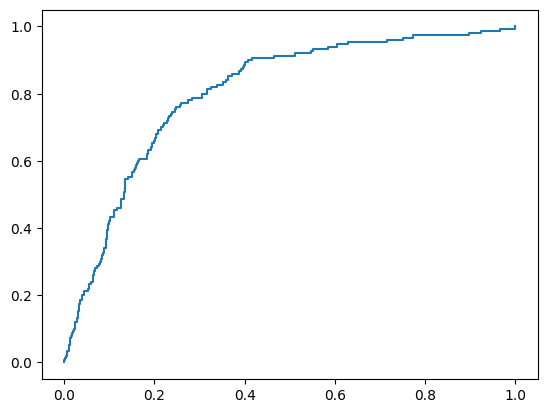

In [189]:
plt.plot(fpr, tpr)